# Exploratory Data Analysis

### Import modules and data

In [39]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import libpysal
import esda
import matplotlib.patches as mpatches
import math
import numpy as np

In [2]:
# data import
DATA_PATH = "../data/merged_ecec_province.geojson"
gdf = gpd.read_file(DATA_PATH)

### Check dataframe dimensions and variables' distributions

In [ ]:
print(f"The dataframe has dimensions {gdf.shape}") # 107 provinces, 63 variables
print(f"The dataframe has {gdf.select_dtypes(include='number').shape[1]} numerical variables") # 47 actual variables

nan_cols = gdf.select_dtypes(exclude='number').columns # only codes and names in non-numeric
print(f"The non numerical columns are: {nan_cols.tolist()}")
print("\tNon-numerical are just codes and names")

In [ ]:
summary = (
    gdf.select_dtypes(include='number').describe()
        .T[['mean', 'std', 'min', 'max']].round(2)
)

print(summary)

Evaluating the distributions shows that `part_rate` displays very low values (min = 0.03, max = 0.06), thus showing a very low standard deviation -> Boxplots will be flat.

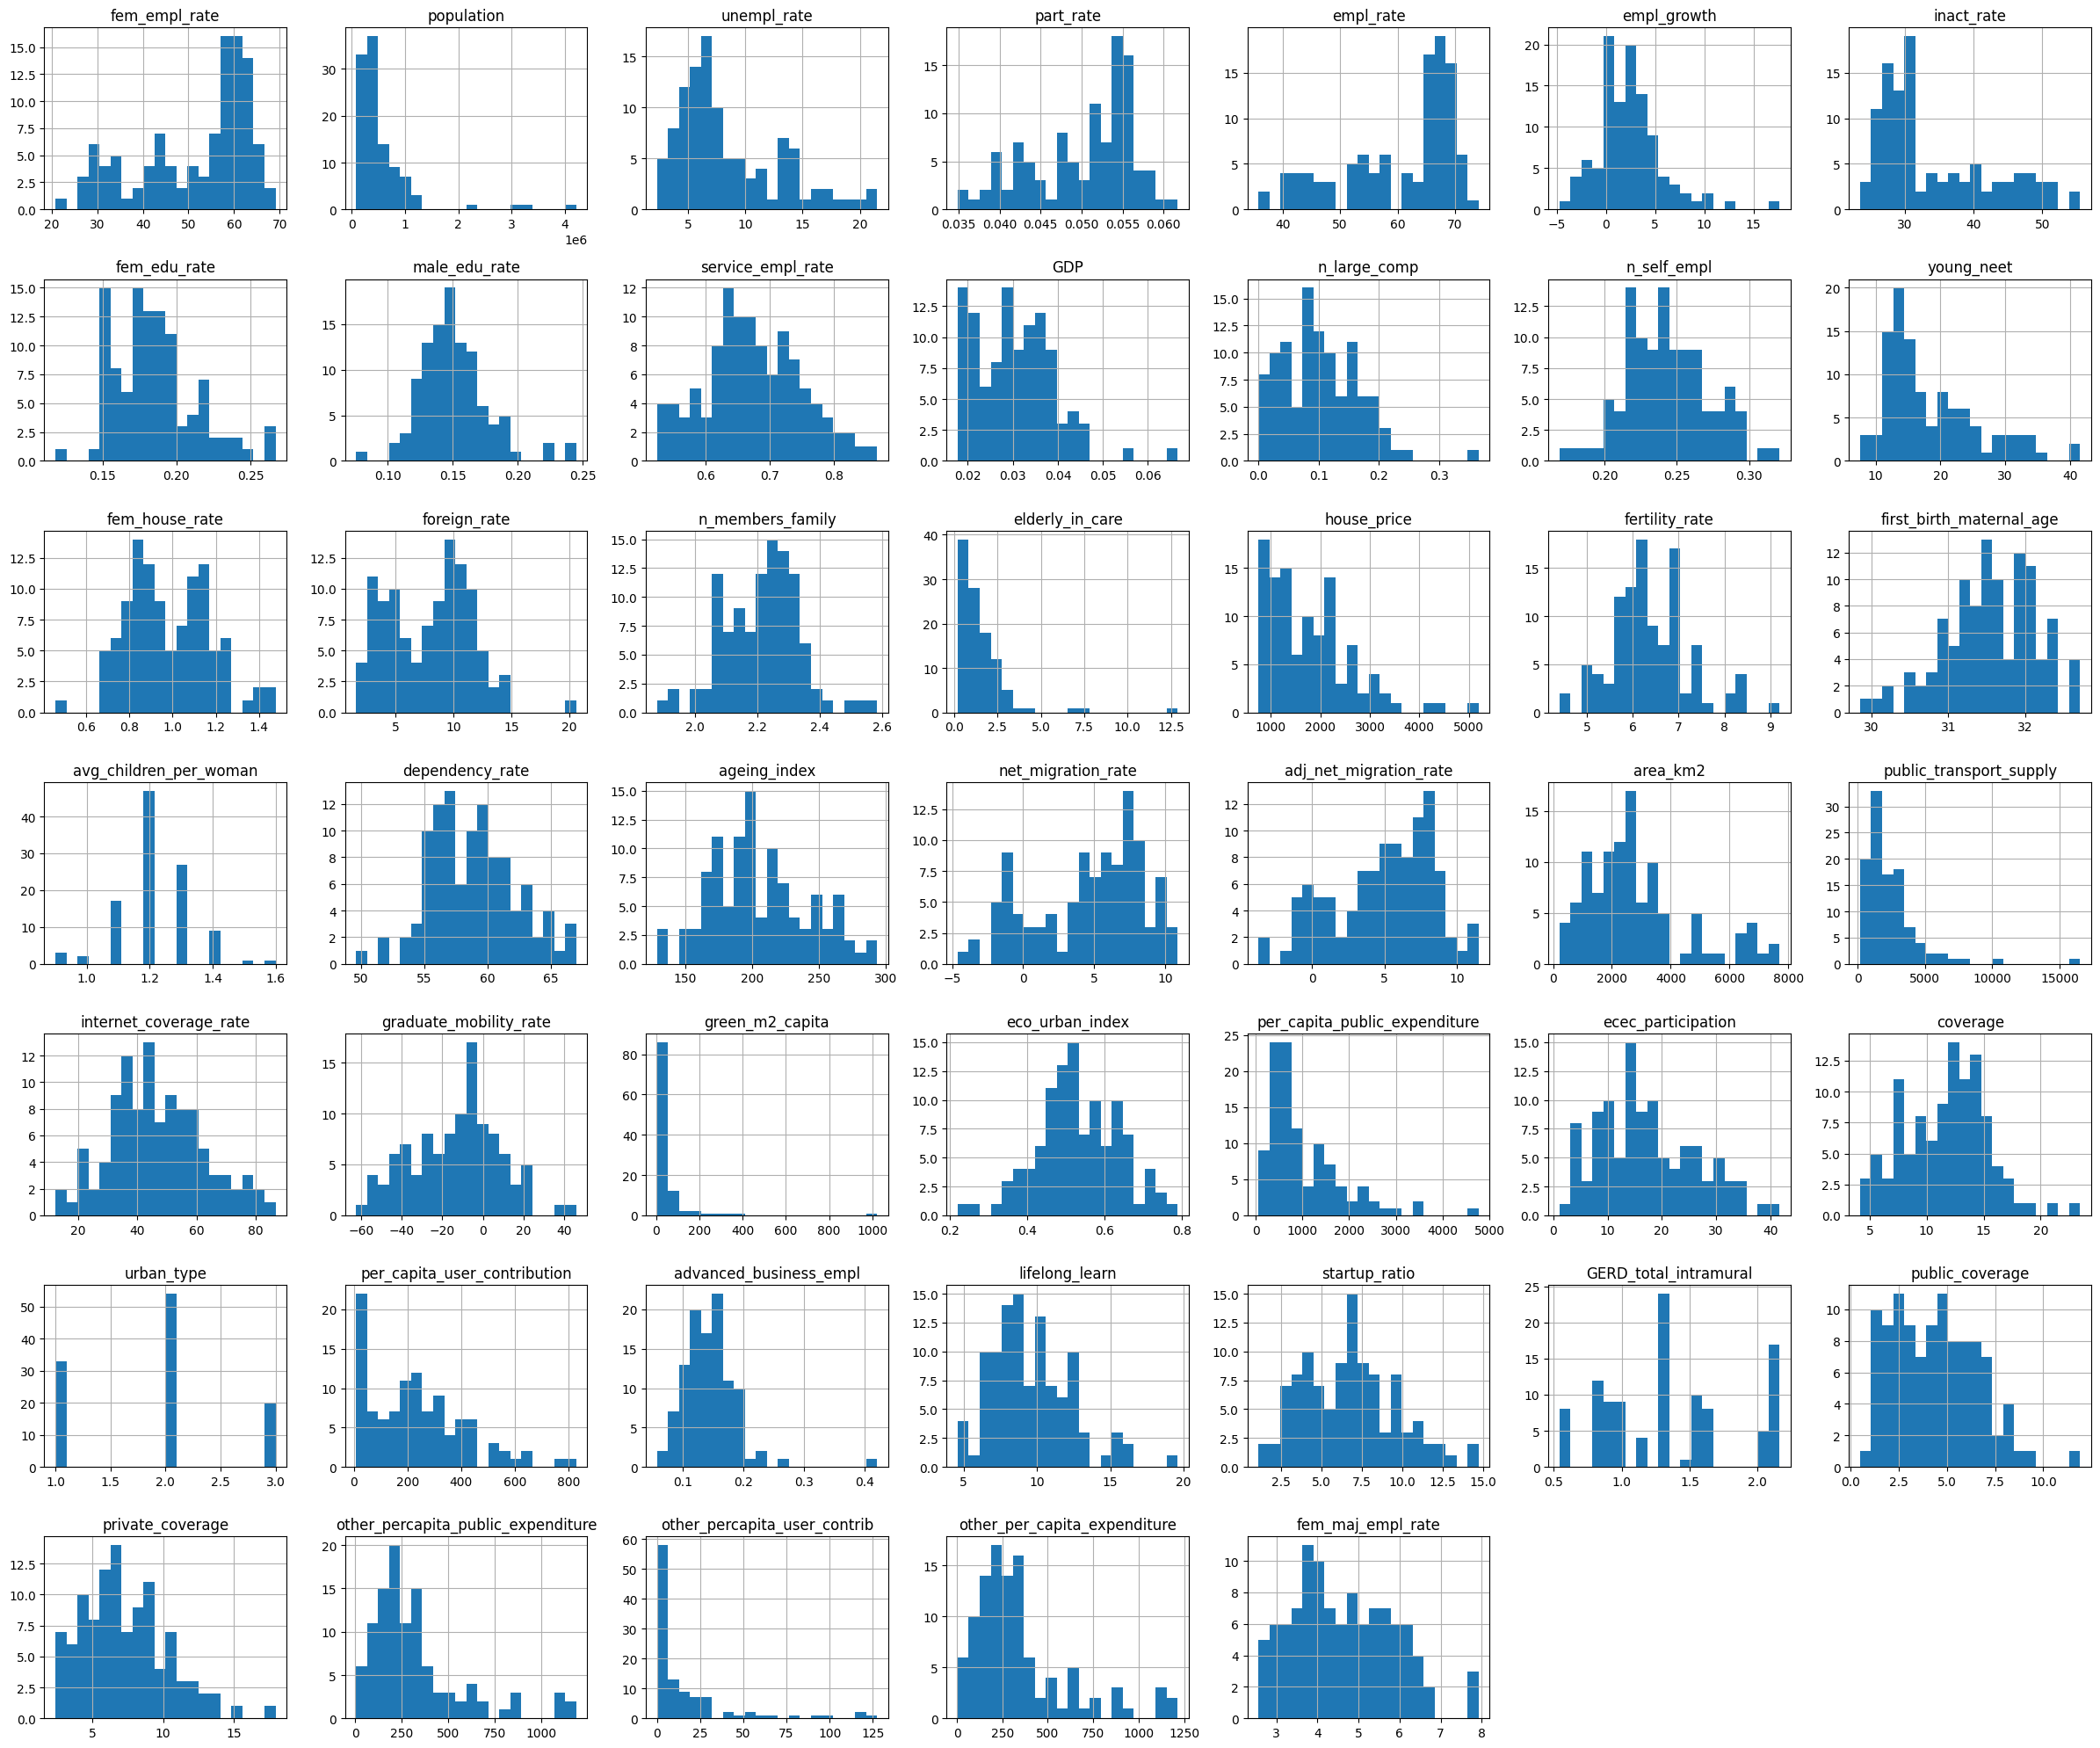

In [10]:
gdf.hist(figsize=(24, 20), bins=20)
plt.tight_layout()
plt.show()

### Correlation Analysis

In [20]:
gdf_num = gdf.select_dtypes(include='number')
gdf_num.corr(method='spearman').style.background_gradient(cmap='coolwarm')

,fem_empl_rate,population,unempl_rate,part_rate,empl_rate,empl_growth,inact_rate,fem_edu_rate,male_edu_rate,service_empl_rate,GDP,n_large_comp,n_self_empl,young_neet,fem_house_rate,foreign_rate,n_members_family,elderly_in_care,house_price,fertility_rate,first_birth_maternal_age,avg_children_per_woman,dependency_rate,ageing_index,net_migration_rate,adj_net_migration_rate,area_km2,public_transport_supply,internet_coverage_rate,graduate_mobility_rate,green_m2_capita,eco_urban_index,per_capita_public_expenditure,ecec_participation,coverage,urban_type,per_capita_user_contribution,advanced_business_empl,lifelong_learn,startup_ratio,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate
fem_empl_rate,1.000000,0.031276,-0.825909,0.928772,0.966557,0.142978,-0.953271,0.309525,0.220595,-0.266683,0.838730,0.578992,-0.448141,-0.824985,-0.823515,0.707173,-0.458623,0.463137,0.609480,-0.219929,0.246143,0.002185,0.405636,0.173715,0.746412,0.719773,-0.072256,0.331530,0.055620,0.803494,0.410524,0.589154,0.751783,0.715655,0.720076,0.060944,0.820782,0.642353,0.572490,0.250337,0.555116,0.561191,0.547589,0.325122,0.415965,0.360689,-0.142911
population,0.031276,1.000000,-0.034929,0.145712,0.067530,0.110268,-0.049921,0.224338,0.333735,0.104720,0.259517,0.416225,-0.214101,-0.091800,-0.264886,0.124630,0.276592,-0.066161,0.489183,0.446802,0.017664,0.320057,-0.447770,-0.536700,-0.036286,-0.008368,0.358647,0.557967,0.321329,0.314613,-0.102342,-0.021599,0.029477,-0.058738,-0.032348,-0.432880,-0.023257,0.418552,0.047367,0.224330,0.034496,-0.276730,0.137851,-0.043055,0.034069,-0.031672,0.350056
unempl_rate,-0.825909,-0.034929,1.000000,-0.800241,-0.865387,-0.107669,0.748986,-0.156348,-0.085187,0.446237,-0.806482,-0.548096,0.387124,0.824471,0.728629,-0.673527,0.265989,-0.466809,-0.553148,0.119134,-0.155203,-0.123100,-0.291827,-0.053109,-0.643462,-0.612218,0.077059,-0.291947,0.083447,-0.679684,-0.319402,-0.598679,-0.551809,-0.558613,-0.643399,-0.086614,-0.656018,-0.593136,-0.393227,-0.192530,-0.452024,-0.384518,-0.577175,-0.253311,-0.378448,-0.285296,0.298699
part_rate,0.928772,0.145712,-0.800241,1.000000,0.955968,0.192054,-0.953640,0.331707,0.254727,-0.315080,0.857805,0.593856,-0.428329,-0.808420,-0.884490,0.792325,-0.296078,0.453373,0.655557,-0.098676,0.234509,0.085619,0.234337,0.006353,0.759970,0.735091,-0.071583,0.369023,0.094488,0.832111,0.373956,0.524586,0.704883,0.692780,0.658565,0.004940,0.776828,0.671242,0.550842,0.225677,0.541055,0.492045,0.509641,0.291062,0.456988,0.323772,-0.195625
empl_rate,0.966557,0.067530,-0.865387,0.955968,1.000000,0.158543,-0.969789,0.289758,0.209458,-0.327454,0.862593,0.602545,-0.441268,-0.844505,-0.833301,0.755499,-0.408213,0.489043,0.636718,-0.175160,0.208224,0.069589,0.379912,0.134837,0.773980,0.743145,-0.061980,0.346265,0.039847,0.809459,0.379642,0.582997,0.726573,0.697769,0.694180,0.072865,0.792570,0.650907,0.555420,0.218571,0.561272,0.531507,0.526950,0.316847,0.410241,0.350617,-0.195541
empl_growth,0.142978,0.110268,-0.107669,0.192054,0.158543,1.000000,-0.157955,0.004400,0.035129,0.052515,0.094671,-0.064491,0.051796,-0.103778,-0.142945,0.026649,0.106060,0.040646,0.175418,0.100416,0.058074,0.138196,-0.077739,-0.074738,0.061807,0.078573,-0.089937,0.023931,0.083307,0.066646,-0.172474,-0.089636,0.114133,0.083393,-0.002305,-0.141719,0.030960,-0.002923,0.099189,-0.137713,-0.018668,0.032039,-0.012341,0.140537,0.055104,0.133582,-0.025628
inact_rate,-0.953271,-0.049921,0.748986,-0.953640,-0.969789,-0.157955,1.000000,-0.319067,-0.242993,0.259336,-0.822604,-0.571853,0.439498,0.792975,0.811357,-0.750909,0.464089,-0.452788,-0.626308,0.234186,-0.229066,-0.006603,-0.432334,-0.204518,-0.802063,-0.776503,0.073317,-0.330153,-0.067577,-0.816700,-0.387343,-0.542470,-0.766133,-0.723894,-0.688109,-0.051183,-0.820919,-0.625236,-0.591517,-0.216135,-0.585633,-0.586758,-0.484100,-0.325117,-0.404654,-0.357824,0.172537
fem_edu_rate,0.30952

### Focus on subset of relevant variables

Some variables have stronger theoretical underpinnings. Thus, I will inspect these in greater detail:
- female employment rate
- unemployment rate
- fem_edu_rate
- GDP
- service_empl_rate 
- avg_children_per_woman
- dependency_rate
- graduate_mobility_rate
- per_capita_public_expenditure
- ecec_participation
- coverage
- per_capita_user_contribution
- fem_maj_empl_rate

In [32]:
var_subset = [
    'prov_name',
    'rip_name',
    'fem_empl_rate', 
    'unemp_rate', 
    'fem_edu_rate',
    'gdp',
    'service_empl_rate', 
    'dependency_rate',
    'graduate_mobility_rate',
    'per_capita_public_expenditure',
    'ecec_participation',
    'coverage',
    'per_capita_user_contribution',
    'fem_maj_empl_rate']

gdf_subset = gdf[[col for col in gdf.columns if col in var_subset]]



In [ ]:
numeric_cols = gdf_subset.select_dtypes(include='number').columns

sns.pairplot(
    gdf_subset,
    vars=numeric_cols,
    hue='rip_name',  # color by this variable
    plot_kws={'alpha': 0.6}
)
plt.show()

### Focus on ECEC variables

Analize only the variables related to ECEC and women labour

In [4]:
ecec_variables = [
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "per_capita_public_expenditure", "per_capita_user_contribution",
    "other_percapita_public_expenditure", "other_percapita_user_contrib",
    "other_per_capita_expenditure"
]

# Variabili Lavoro Femminile
labour_variables = [
    "fem_empl_rate", "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate"
]


eda_df = gdf_num[ecec_variables + labour_variables]

In [9]:
print(eda_df.std().sort_values()) # very different standard deviations

part_rate                               0.006247
fem_edu_rate                            0.027722
fem_house_rate                          0.192405
fem_maj_empl_rate                       1.223030
public_coverage                         2.197102
private_coverage                        3.013569
coverage                                3.716104
unempl_rate                             4.447776
ecec_participation                      8.927299
fem_empl_rate                          12.406201
other_percapita_user_contrib           26.321117
per_capita_user_contribution          177.678746
other_percapita_public_expenditure    256.434322
other_per_capita_expenditure          267.566490
per_capita_public_expenditure         818.311320
dtype: float64


In [13]:
stdev_sorted = eda_df.std().sort_values().index
variables_by_stdev = {
    "low variance": stdev_sorted[:8].tolist(),
    "medium variance" : stdev_sorted[8:11].tolist(),
    "high variance" : stdev_sorted[11:-1].tolist(),
    "per capita public expenditure" : [stdev_sorted[-1]]
    }


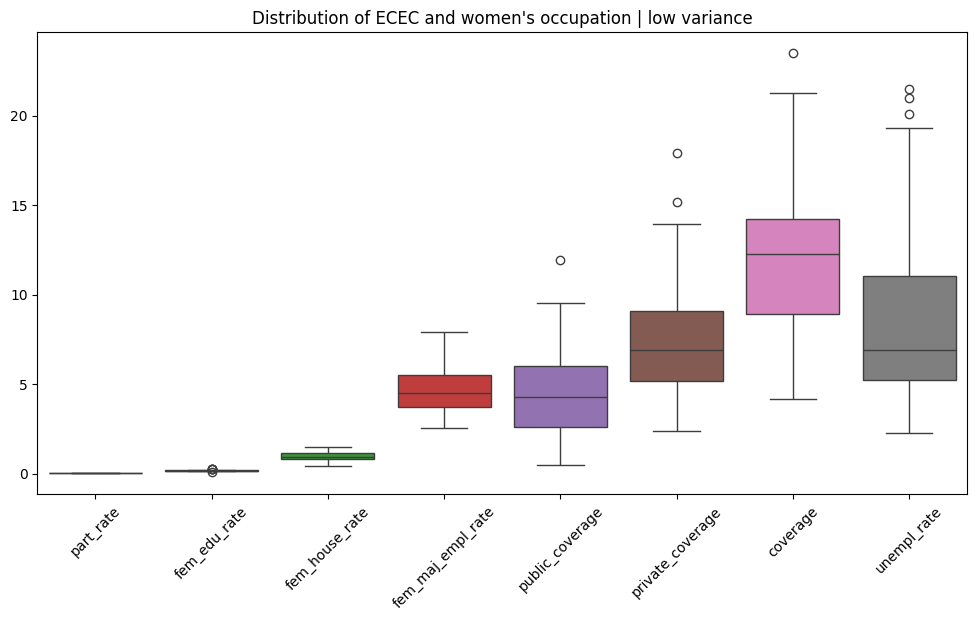

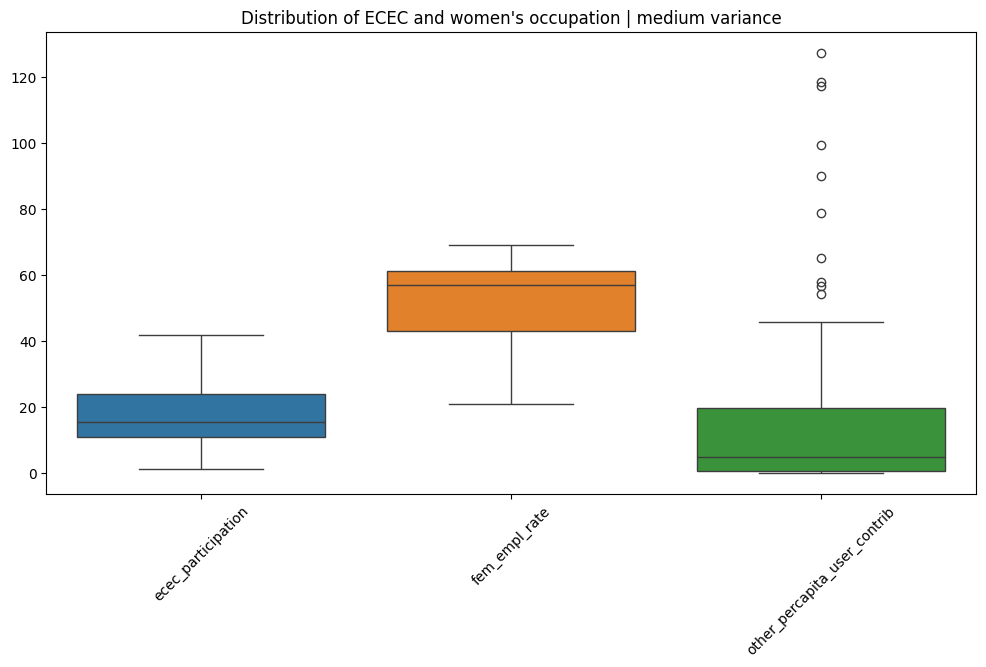

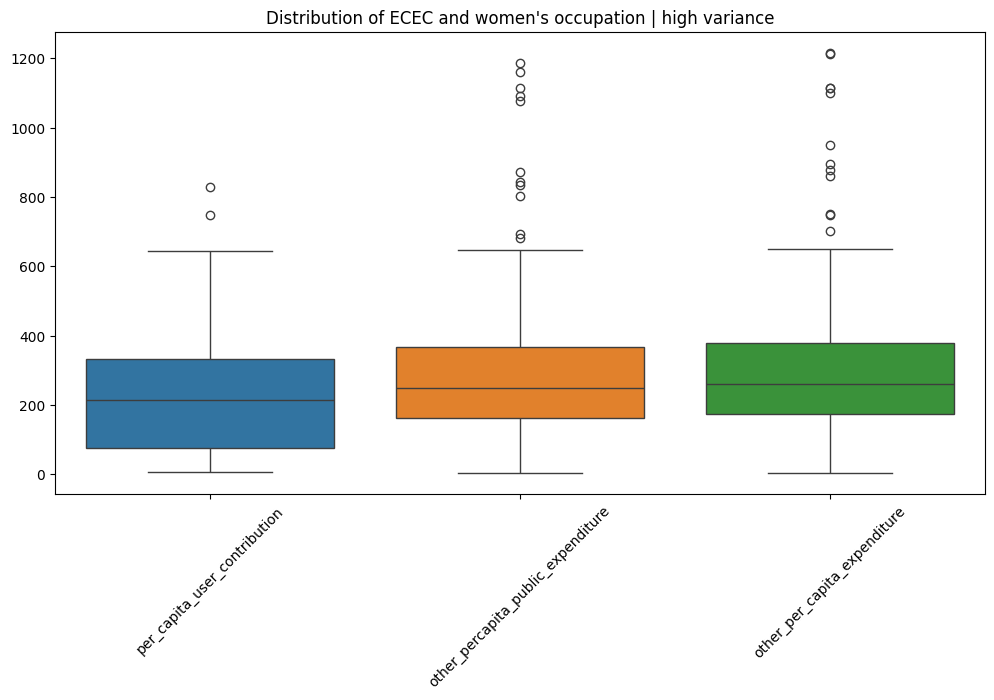

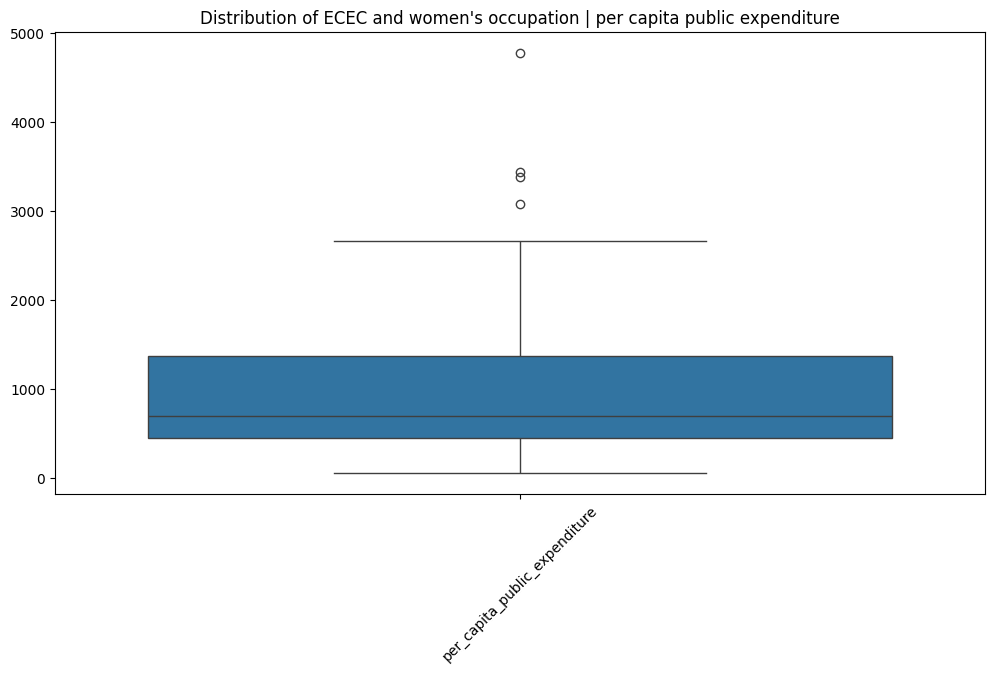

In [ ]:
for group_name, var_list in variables_by_stdev.items():
    
    plt.figure(figsize=(12,6))
    sns.boxplot(eda_df[var_list])
    plt.xticks(rotation=45)
    plt.title(f"Distribution of ECEC and women's occupation | {group_name}")
    plt.show()

#TODO : add back prov_code so we can plot 'outliers' labels

Correlation for ECEC / Women's occupation's variables

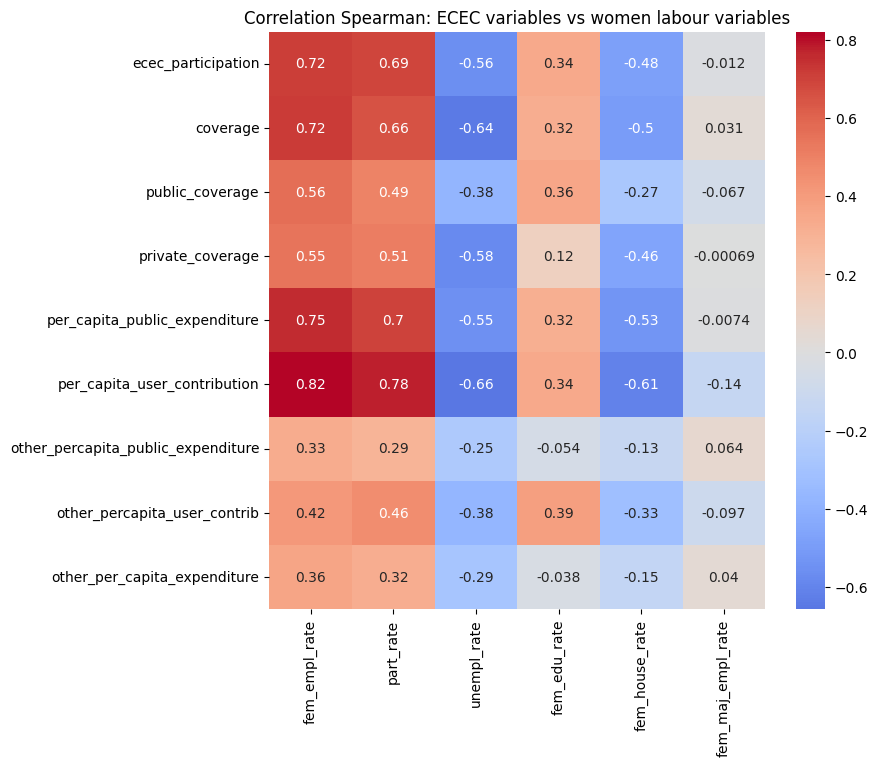

,fem_empl_rate,part_rate,unempl_rate,fem_edu_rate,fem_house_rate,fem_maj_empl_rate
ecec_participation,0.715655,0.692780,-0.558613,0.341399,-0.482837,-0.011849
coverage,0.720076,0.658565,-0.643399,0.324634,-0.503497,0.030731
public_coverage,0.561191,0.492045,-0.384518,0.357413,-0.273820,-0.067497
private_coverage,0.547589,0.509641,-0.577175,0.123881,-0.462848,-0.000686
per_capita_public_expenditure,0.751783,0.704883,-0.551809,0.318707,-0.532700,-0.007357
per_capita_user_contribution,0.820782,0.776828,-0.656018,0.341317,-0.607761,-0.141059
other_percapita_public_expenditure,0.325122,0.291062,-0.253311,-0.054233,-0.129323,0.064421
other_percapita_user_contrib,0.415965,0.456988,-0.378448,0.387612,-0.325544,-0.097335
other_per_capita_expenditure,0.360689,0.323772,-0.285296,-0.037981,-0.153353,0.039656


In [21]:
corr = gdf_num[ecec_variables + labour_variables].corr(method="spearman")

cross_corr = corr.loc[ecec_variables, labour_variables]

plt.figure(figsize=(8, len(ecec_variables)*0.5 + 3))
sns.heatmap(cross_corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Spearman: ECEC variables vs women labour variables")
plt.show()

cross_corr

In [ ]:
abs_corr = cross_corr.abs().stack().sort_values(ascending=False)
abs_corr

## Spatial Visualisation

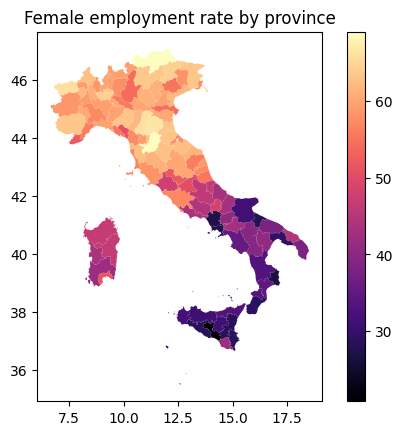

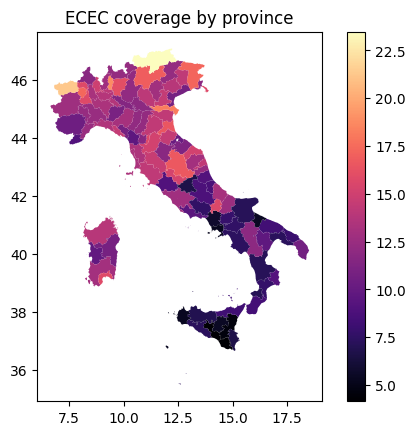

In [27]:
gdf.plot(column="fem_empl_rate", cmap="magma", legend=True)
plt.title("Female employment rate by province")
plt.show()

gdf.plot(column="coverage", cmap="magma", legend=True)
plt.title("ECEC coverage by province")
plt.show()

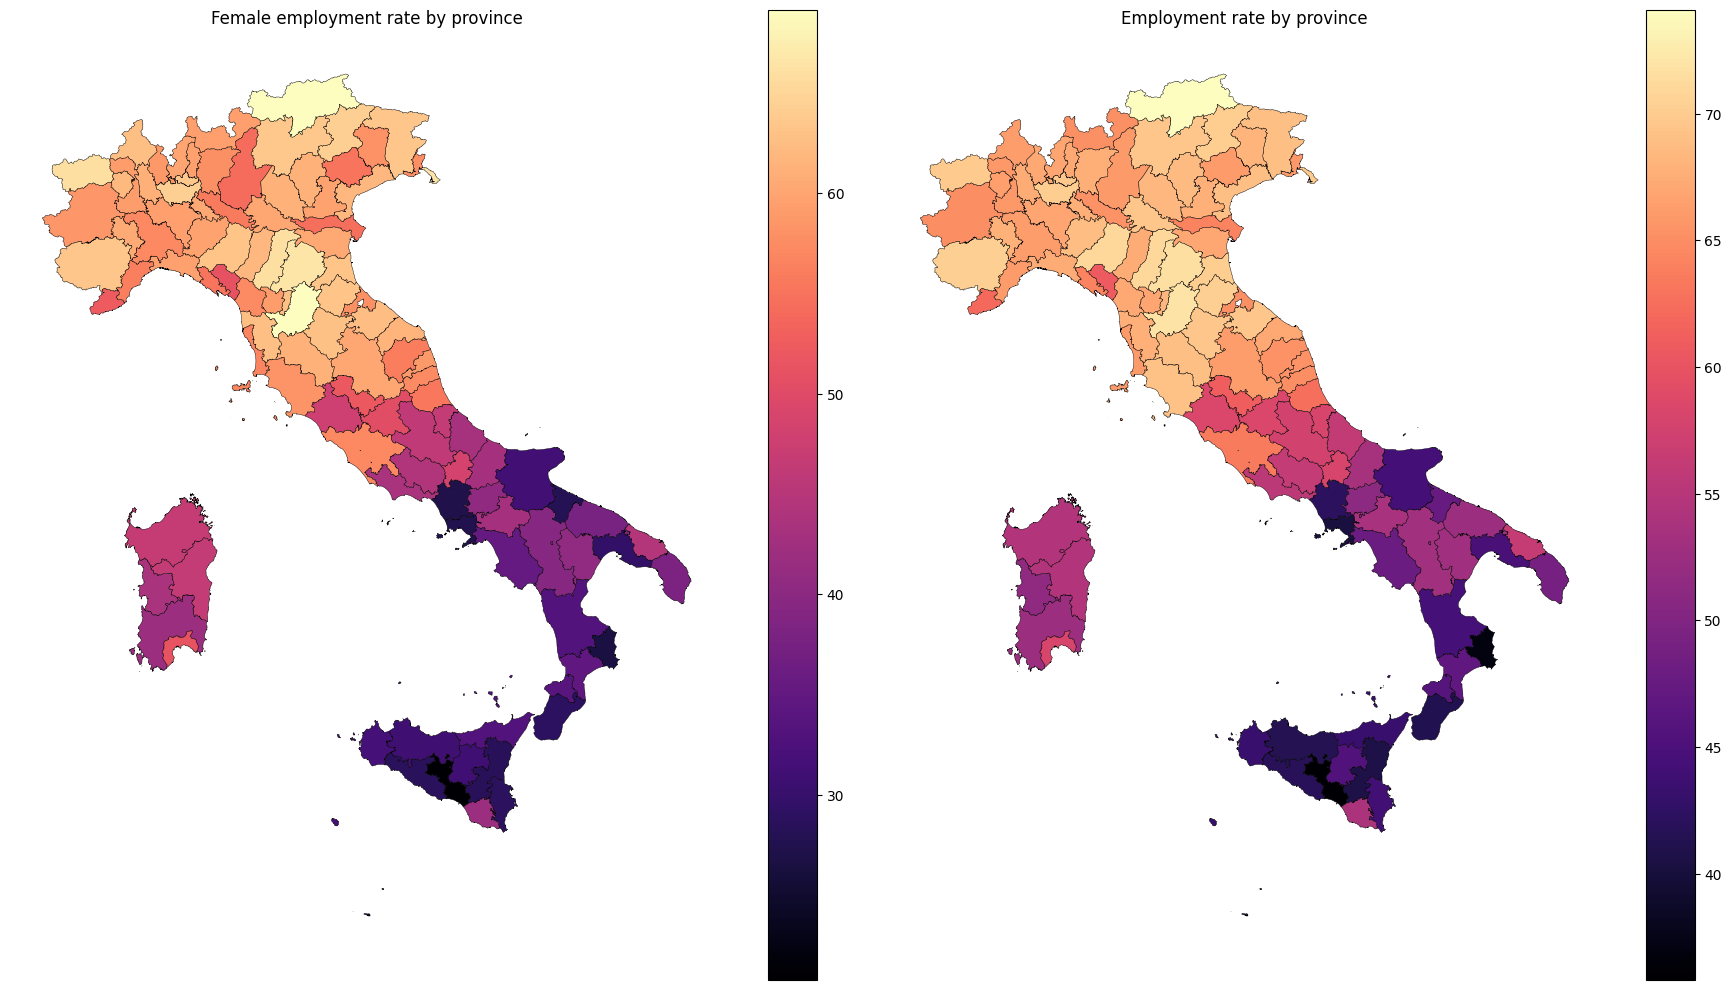

In [28]:
# Plot provinces and colour them based on female employment rate and we compare it with the global employement rate


fig, axs = plt.subplots(1, 2, figsize=(18, 10))

gdf.plot(
    column="fem_empl_rate",
    cmap="magma",
    edgecolor="black",
    linewidth=0.3,
    ax=axs[0],
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)

axs[0].set_title("Female employment rate by province")
axs[0].axis("off")

gdf.plot(
    column="empl_rate",
    cmap="magma",  
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    ax=axs[1],
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)
axs[1].set_title("Employment rate by province")
axs[1].axis("off")

plt.tight_layout()
plt.show()


Let's focus on the differences between the global employement rate and the female employement rate

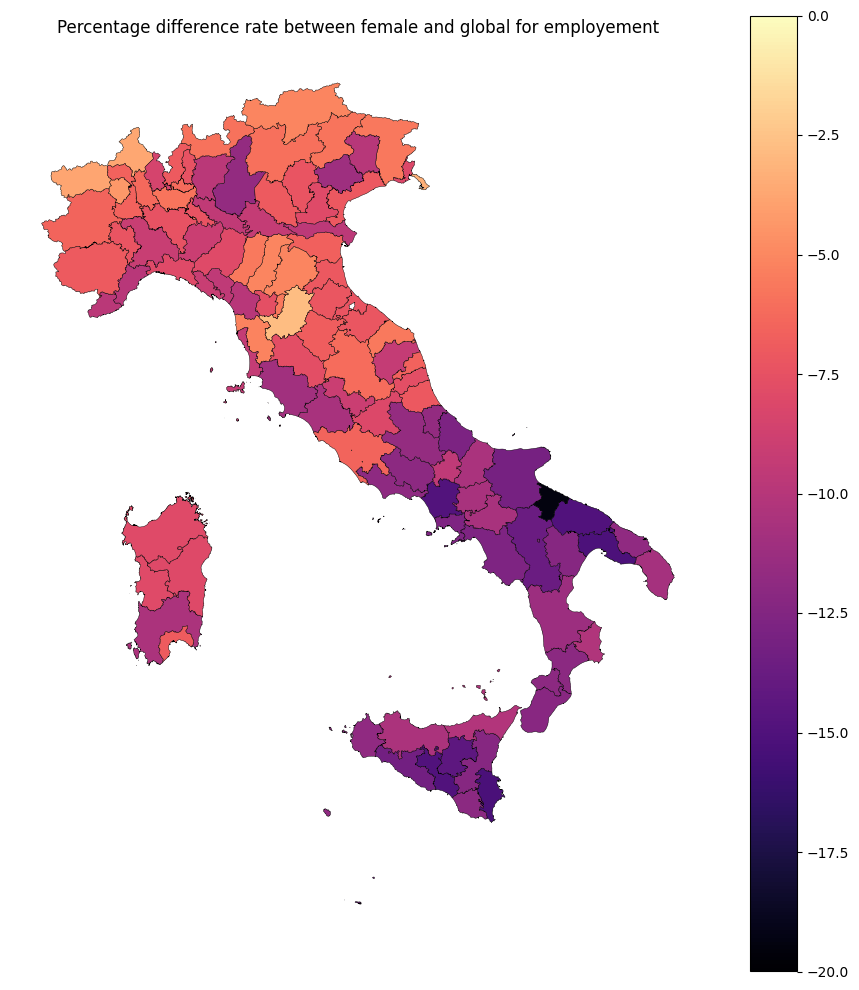

maximal value : -2.8
minimal value : -19.4


In [29]:
gdf_copy=gdf.copy()

gdf_copy["diff_empl_female_vs_glob"]=gdf["fem_empl_rate"]-gdf["empl_rate"]

vmin=round(min(gdf_copy["diff_empl_female_vs_glob"]),2)
vmax=round(max(gdf_copy["diff_empl_female_vs_glob"]),2)


ax = gdf_copy.plot(
    column="diff_empl_female_vs_glob",
    cmap="magma",
    edgecolor="black",
    vmin=-20,
    vmax=0,
    linewidth=0.3,
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)




plt.title("Percentage difference rate between female and global for employement")
plt.axis("off")
plt.tight_layout()
plt.show()
print("maximal value :",vmax)
print("minimal value :",vmin)

### Analysis of occupational gap

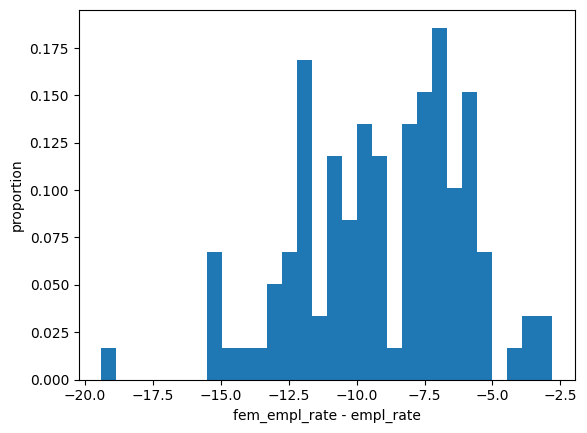

third quartile :  -6.950000000000003


In [37]:
plt.hist(gdf_copy["diff_empl_female_vs_glob"],bins=30, density=True)

plt.xlabel("fem_empl_rate - empl_rate")
plt.ylabel("proportion")
plt.show()

third_quartile=gdf_copy["diff_empl_female_vs_glob"].quantile(q=0.75)

print("third quartile : ",third_quartile)


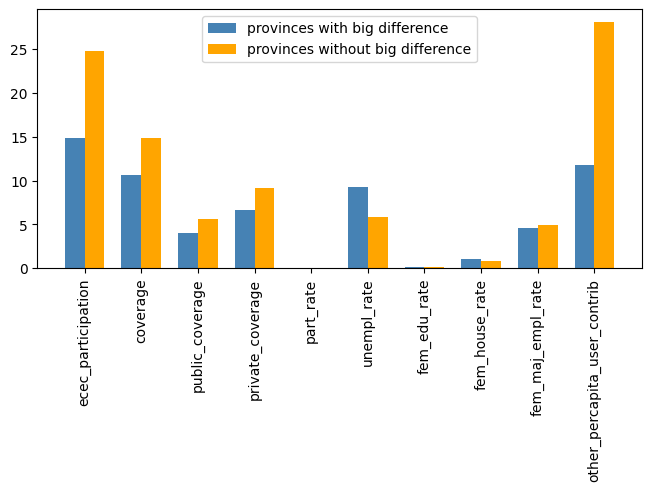

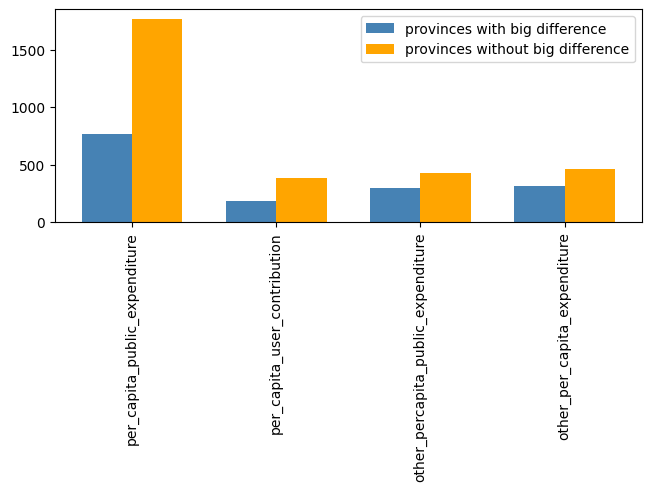

In [40]:
gdf_copy["big_difference_male_vs_female"]=0
gdf_copy.loc[ gdf_copy["diff_empl_female_vs_glob"]<third_quartile ,"big_difference_male_vs_female"]=1

scale1_var=[
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate","other_percapita_user_contrib"

]

scale2_var=[ "per_capita_public_expenditure", "per_capita_user_contribution",  "other_percapita_public_expenditure","other_per_capita_expenditure"]


mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale1_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale1_var].mean(axis=0)

fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(scale1_var))
width = 0.35  

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale1_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


fig, ax = plt.subplots(layout='constrained')
x = np.arange(len(scale2_var))

mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale2_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale2_var].mean(axis=0)

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale2_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


### Check spatial autocollinearity

In [44]:
gdf_check = gdf_subset.copy()
gdf_check = gpd.GeoDataFrame(gdf_check, geometry=gdf.geometry)
w = libpysal.weights.Queen.from_dataframe(gdf_check, use_index=True)
w.transform = 'r'

for col in gdf_check.select_dtypes(include='number').columns:
    y = gdf_check[col].values
    moran = esda.Moran(y, w)
    print(f"{col}: Moran's I = {moran.I} | p-value = {moran.p_sim}")

/home/luca/Projects/Bayesian-Statistics-Project/.venv/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


fem_empl_rate: Moran's I = 0.8671870880288873 | p-value = 0.001
fem_edu_rate: Moran's I = 0.16445991612883132 | p-value = 0.006
service_empl_rate: Moran's I = 0.18095693561948895 | p-value = 0.003
dependency_rate: Moran's I = 0.5264410836644587 | p-value = 0.001
graduate_mobility_rate: Moran's I = 0.6477011444774634 | p-value = 0.001
per_capita_public_expenditure: Moran's I = 0.5091312510233326 | p-value = 0.001
ecec_participation: Moran's I = 0.691492301259031 | p-value = 0.001
coverage: Moran's I = 0.5680714866113351 | p-value = 0.001
per_capita_user_contribution: Moran's I = 0.5765270515854904 | p-value = 0.001
fem_maj_empl_rate: Moran's I = 0.10057348720296877 | p-value = 0.067


Focusing on our response variable `fem_empl_rate`, I investigate Moran's I clusters

/home/luca/Projects/Bayesian-Statistics-Project/.venv/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


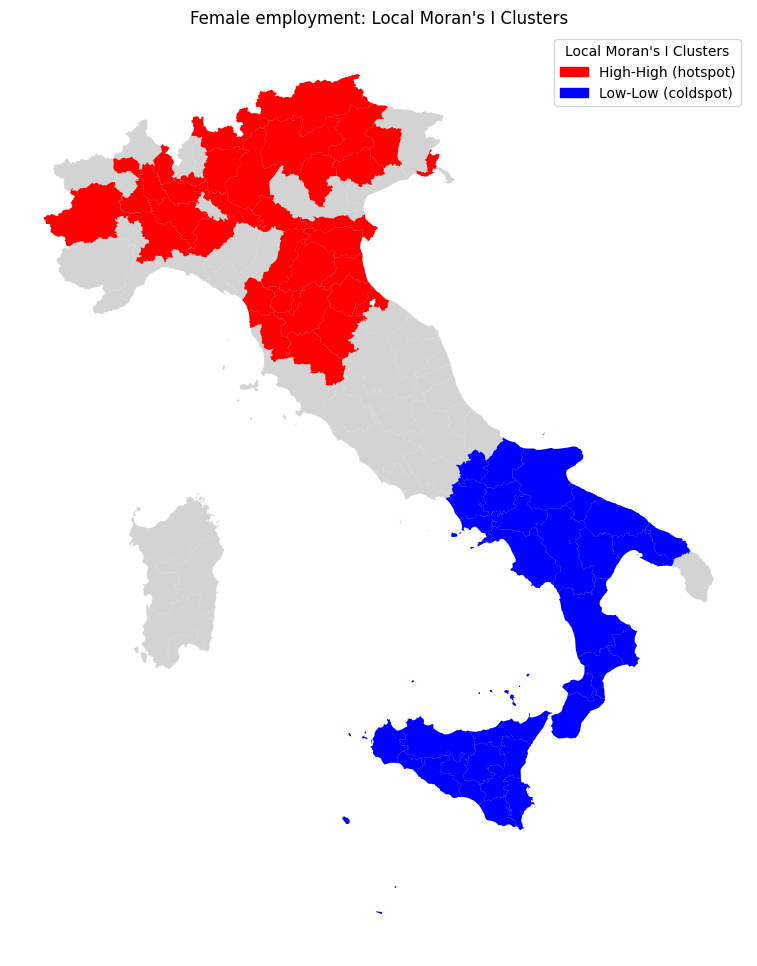

In [45]:
# Spatial weights
w = libpysal.weights.Queen.from_dataframe(gdf_check, use_index=True)
w.transform = 'r'

# Variable
y = gdf_check['fem_empl_rate'].values

# Local Moran
lm = esda.Moran_Local(y, w)

# Cluster classification
sig = lm.p_sim < 0.05
labels = np.array(['Not significant'] * len(lm.q))
labels[(lm.q == 1) & sig] = 'HH'
labels[(lm.q == 2) & sig] = 'LH'
labels[(lm.q == 3) & sig] = 'LL'
labels[(lm.q == 4) & sig] = 'HL'
gdf_check['cluster'] = labels

# Plot
cluster_colors = {'HH':'red', 'LL':'blue', 'HL':'pink', 'LH':'cyan'}
cluster_labels = {
    'HH': 'High-High (hotspot)',
    'LL': 'Low-Low (coldspot)',
    'HL': 'High-Low (outlier)',
    'LH': 'Low-High (outlier)'
}

fig, ax = plt.subplots(figsize=(12, 12))
gdf_check.plot(color='lightgrey', ax=ax)

for cluster, color in cluster_colors.items():
    subset = gdf_check[gdf_check['cluster'] == cluster]
    if not subset.empty:
        subset.plot(color=color, ax=ax)

patches = [mpatches.Patch(color=color, label=cluster_labels[cluster])
           for cluster, color in cluster_colors.items()
           if not gdf_check[gdf_check['cluster']==cluster].empty]

plt.legend(handles=patches, title="Local Moran's I Clusters")
ax.set_title("Female employment: Local Moran's I Clusters")
ax.axis('off')
plt.show()
